# Interactive Canvas for Devanagari Character Recognition

Draw a Devanagari character on the canvas and get predictions from all three models (CNN, ViT, and Hybrid).


In [10]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set paths
MODELS_DIR = Path('../models')

# Load class mappings
with open('../utils/class_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)
    class_to_idx = mappings['class_to_idx']
    idx_to_class = mappings['idx_to_class']
    classes = mappings['classes']

num_classes = len(classes)
print(f"Number of classes: {num_classes}")


Using device: cpu
Number of classes: 46


In [11]:
# Redefine models (same as training/evaluation notebooks)
class CNNModel(nn.Module):
    def __init__(self, num_classes=46):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(0.1)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ViTModel(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128, 
                 num_heads=4, num_layers=4, num_classes=46):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(0.1)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token_final = x[:, 0]
        return self.head(cls_token_final)

class HybridModel(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.vit_patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=64)
        num_patches = self.vit_patch_embed.n_patches
        self.vit_cls_token = nn.Parameter(torch.randn(1, 1, 64))
        self.vit_pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, 64))
        self.vit_blocks = nn.ModuleList([TransformerBlock(embed_dim=64, num_heads=2) for _ in range(2)])
        self.vit_norm = nn.LayerNorm(64)
        self.fusion = nn.Sequential(
            nn.Linear(128 * 8 * 8 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        vit_out = self.vit_patch_embed(x)
        B = vit_out.shape[0]
        cls_tokens = self.vit_cls_token.expand(B, -1, -1)
        vit_out = torch.cat((cls_tokens, vit_out), dim=1)
        vit_out = vit_out + self.vit_pos_embed
        for block in self.vit_blocks:
            vit_out = block(vit_out)
        vit_out = self.vit_norm(vit_out)
        vit_out = vit_out[:, 0]
        combined = torch.cat([cnn_out, vit_out], dim=1)
        return self.fusion(combined)

print("Models defined")


Models defined


In [12]:
# Load models
print("Loading models...")
cnn_model = CNNModel(num_classes=num_classes)
cnn_model.load_state_dict(torch.load(MODELS_DIR / 'cnn_model.pth', map_location=device))
cnn_model = cnn_model.to(device)
cnn_model.eval()

vit_model = ViTModel(num_classes=num_classes)
vit_model.load_state_dict(torch.load(MODELS_DIR / 'vit_model.pth', map_location=device))
vit_model = vit_model.to(device)
vit_model.eval()

hybrid_model = HybridModel(num_classes=num_classes)
hybrid_model.load_state_dict(torch.load(MODELS_DIR / 'hybrid_model.pth', map_location=device))
hybrid_model = hybrid_model.to(device)
hybrid_model.eval()

print("All models loaded successfully!")


Loading models...
All models loaded successfully!


In [13]:
# Transform for prediction
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess_drawing(drawing_array):
    """Convert drawing array to model input format"""
    # Convert to PIL Image
    img = Image.fromarray(drawing_array.astype('uint8'), mode='RGB')
    # Apply transform
    img_tensor = transform(img).unsqueeze(0)
    return img_tensor.to(device)

def predict_with_model(model, img_tensor):
    """Get predictions from a model"""
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probs, k=5)
    return top_probs.cpu().numpy()[0], top_indices.cpu().numpy()[0]

print("Helper functions defined")


Helper functions defined


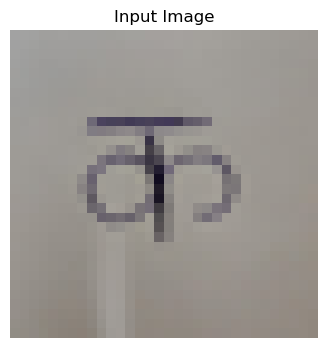


================= Predictions =================

CNN:
 1. digit_0 → 34.96%
 2. digit_1 → 15.26%
 3. digit_2 → 13.65%
 4. digit_7 → 8.30%
 5. character_17_tha → 8.01%

Vision Transformer:
 1. character_2_kha → 26.90%
 2. character_34_chhya → 16.38%
 3. character_17_tha → 13.52%
 4. character_1_ka → 11.03%
 5. character_19_dha → 7.34%

Hybrid:
 1. digit_1 → 97.57%
 2. digit_2 → 1.31%
 3. digit_0 → 0.47%
 4. character_16_tabala → 0.26%
 5. digit_8 → 0.18%



In [16]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display

def load_and_preprocess_image(image_path):
    """Load image file → preprocess for model"""
    img = Image.open(image_path).convert("RGB")
    img = img.resize((32, 32))
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img, img_tensor

def predict_image(image_path):
    """Show image + top predictions from all models"""

    try:
        img, img_tensor = load_and_preprocess_image(image_path)
    except:
        print("❌ Error reading image. Check path again.")
        return

    # Show image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Input Image")
    plt.show()

    # Predict using models
    models = [
        ("CNN", cnn_model),
        ("Vision Transformer", vit_model),
        ("Hybrid", hybrid_model)
    ]

    print("\n================= Predictions =================")

    for name, model in models:
        probs, indices = predict_with_model(model, img_tensor)
        print(f"\n{name}:")
        for i, (p, idx) in enumerate(zip(probs, indices)):
            print(f" {i+1}. {idx_to_class[idx]} → {p*100:.2f}%")

    print("================================================\n")

# =============================
# 🔥 TEST PREDICTION HERE
# =============================
image_path = "ka.jpg"  # change to your image file
predict_image(image_path)


#IF WE TRAINED MODELS TO HIGHER EPOCH 20-30 epochs THE VIT AND HYBRID WILL PERFORM WELL , HERE WE HAVE SET EPOCH TO 1 ONLY FOR FASTER MODEL TRAINING BUT
#THAT ARE NOT AS ACCURATE


In [14]:
# ==== Imports (Required) ====
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Disable toolbar for better drawing
plt.rcParams['toolbar'] = 'None'

# ==== Drawing Canvas Class ====
class DrawingCanvas:
    def __init__(self, width=400, height=400):
        self.width = width
        self.height = height
        self.drawing = np.ones((height, width, 3), dtype=np.uint8) * 255
        self.is_drawing = False
        self.last_pos = None
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(14, 6))
        self.ax1.set_title('Draw Here (Click + Drag)', fontsize=12)
        self.ax1.axis('off')
        self.ax2.axis('off')
        self.ax2.set_title('Predictions', fontsize=12)
        
        self.img_display = self.ax1.imshow(self.drawing)
        
        self.fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

    def update_display(self):
        self.ax1.clear()
        self.ax1.imshow(self.drawing)
        self.ax1.set_title('Draw Here (Click + Drag)', fontsize=12)
        self.ax1.axis('off')
        self.fig.canvas.draw()
        
    def on_press(self, event):
        if event.inaxes != self.ax1: return
        self.is_drawing = True
        self.last_pos = (int(event.xdata), int(event.ydata))
        
    def on_motion(self, event):
        if not self.is_drawing or event.inaxes != self.ax1: return
        if self.last_pos is None: return
        
        x, y = int(event.xdata), int(event.ydata)
        cv2.line(self.drawing, self.last_pos, (x, y), (0, 0, 0), 15)
        self.last_pos = (x, y)
        self.update_display()
        
    def on_release(self, event):
        self.is_drawing = False
        self.last_pos = None
        
    def clear(self):
        self.drawing = np.ones((self.height, self.width, 3), dtype=np.uint8) * 255
        self.update_display()
        
    def predict(self):
        img_tensor = preprocess_drawing(self.drawing)

        # Model Predictions (Must be defined earlier)
        cnn_probs, cnn_indices = predict_with_model(cnn_model, img_tensor)
        vit_probs, vit_indices = predict_with_model(vit_model, img_tensor)
        hybrid_probs, hybrid_indices = predict_with_model(hybrid_model, img_tensor)

        self.ax2.clear()
        self.ax2.axis('off')
        self.ax2.set_title("Top 5 Predictions", fontsize=14, fontweight='bold')
        
        y = 0.95
        models = [
            ("CNN", cnn_probs, cnn_indices),
            ("ViT", vit_probs, vit_indices),
            ("Hybrid", hybrid_probs, hybrid_indices),
        ]

        for name, probs, idxs in models:
            self.ax2.text(0.02, y, f"{name}:", fontsize=12, fontweight="bold", color="blue")
            y -= 0.12
            for i, (p, idx) in enumerate(zip(probs, idxs)):
                label = idx_to_class[idx]
                color = "green" if i == 0 else "black"
                self.ax2.text(0.05, y, f"{i+1}. {label} — {p*100:.2f}%", fontsize=10, color=color)
                y -= 0.08
            y -= 0.05
        
        self.fig.canvas.draw()

print("Drawing canvas ready!")


Drawing canvas ready!


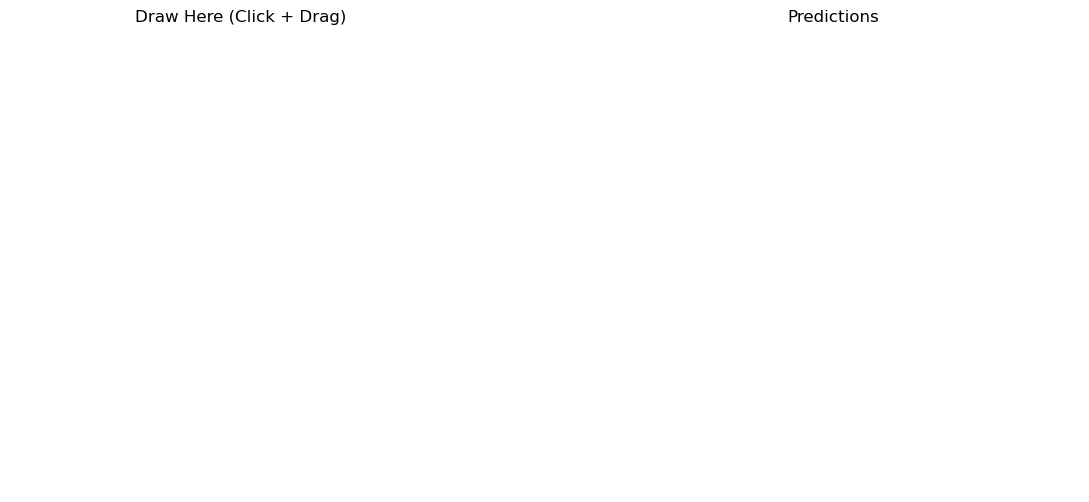


Instructions:
✔ Draw a character by clicking + dragging on the left area
✔ Click 'Predict' to see results
✔ Click 'Clear Canvas' to reset


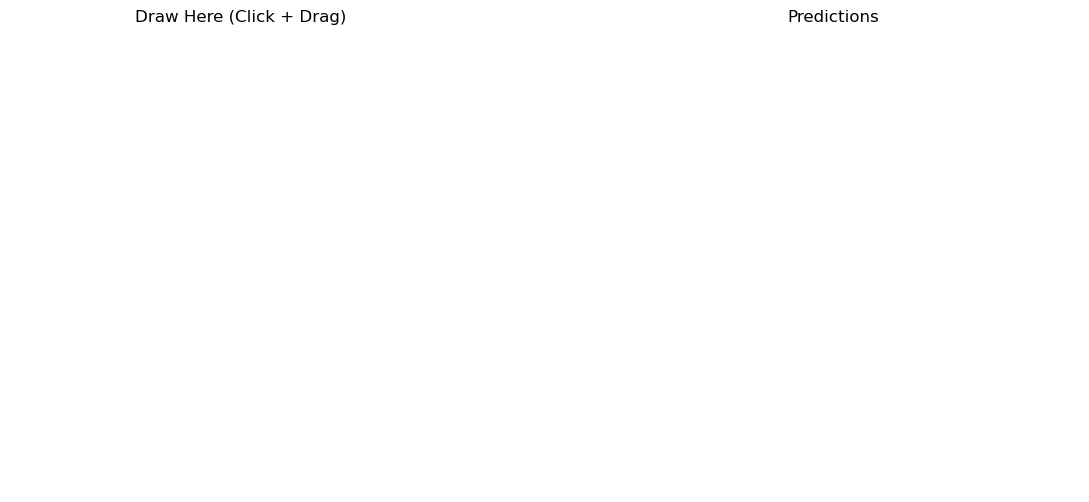

In [15]:
# Create canvas instance
canvas = DrawingCanvas()

# Buttons UI
clear_btn = widgets.Button(description="Clear Canvas", layout=widgets.Layout(width='150px'), style={'button_color': '#ff6b6b'})
predict_btn = widgets.Button(description="Predict", layout=widgets.Layout(width='150px'), style={'button_color': '#4ecdc4'})

clear_btn.on_click(lambda b: canvas.clear())
predict_btn.on_click(lambda b: canvas.predict())

# Display UI + Canvas
display(widgets.HBox([clear_btn, predict_btn]))
display(canvas.fig)

print("\n" + "="*55)
print("Instructions:")
print("✔ Draw a character by clicking + dragging on the left area")
print("✔ Click 'Predict' to see results")
print("✔ Click 'Clear Canvas' to reset")
print("="*55)


In [17]:
# import torch.nn.functional as F

# def predict_with_model(model, img_tensor):
#     """Runs forward pass and returns top-5 class predictions"""
#     model.eval()
#     with torch.no_grad():
#         outputs = model(img_tensor)
#         probs = F.softmax(outputs, dim=1)
#         top_probs, top_indices = torch.topk(probs, k=5)

#     return top_probs.cpu().numpy()[0], top_indices.cpu().numpy()[0]


In [18]:
# import cv2
# import numpy as np
# import torch


# drawing = False
# last_point = None
# canvas = np.ones((400, 400, 3), dtype=np.uint8) * 255

# def preprocess_for_model(img):
#     # Convert to grayscale
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
#     # Threshold
#     _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    
#     # Find bounding box of drawing
#     coords = cv2.findNonZero(thresh)
#     if coords is None:
#         return None, None
        
#     x, y, w, h = cv2.boundingRect(coords)

#     # Crop around the drawing
#     cropped = thresh[y:y+h, x:x+w]

#     # Resize to keep aspect ratio
#     resized = cv2.resize(cropped, (28, 28), interpolation=cv2.INTER_AREA)

#     # Pad to 32x32 like training images
#     final = np.pad(resized, ((2,2),(2,2)), "constant", constant_values=0)

#     # Normalize and add batch dimension
#     img_tensor = final.astype("float32") / 255.0
#     img_tensor = np.expand_dims(img_tensor, axis=(0, -1))

#     return img_tensor, final


# def draw(event, x, y, flags, param):
#     global drawing, last_point, canvas

#     if event == cv2.EVENT_LBUTTONDOWN:
#         drawing = True
#         last_point = (x, y)
    
#     elif event == cv2.EVENT_MOUSEMOVE and drawing:
#         cv2.line(canvas, last_point, (x, y), (0, 0, 0), 20)
#         last_point = (x, y)
    
#     elif event == cv2.EVENT_LBUTTONUP:
#         drawing = False
#         last_point = None


# cv2.namedWindow("Draw Character")
# cv2.setMouseCallback("Draw Character", draw)

# print("\nControls:")
# print("🖌 Draw with mouse")
# print("🧠 Press P → Predict")
# print("🧽 Press C → Clear")
# print("❌ Press Q → Quit\n")

# while True:
#     cv2.imshow("Draw Character", canvas)
#     key = cv2.waitKey(1) & 0xFF

#     if key == ord('p'):
#         img_tensor, pre_img = preprocess_for_model(canvas)
#         if img_tensor is None:
#             print("Nothing drawn!")
#             continue
    
#         img_t = torch.tensor(img_tensor, dtype=torch.float32)

#         # Show preprocessed image (what model sees)
#         cv2.imshow("Model Input (32x32)", pre_img)

#         cnn_probs, cnn_idx = predict_with_model(cnn_model, img_t)
#         vit_probs, vit_idx = predict_with_model(vit_model, img_t)
#         hybrid_probs, hybrid_idx = predict_with_model(hybrid_model, img_t)

#         print("\n========= Predictions =========")
#         print("CNN    :", idx_to_class[cnn_idx[0]], f"({cnn_probs[0]*100:.2f}%)")
#         print("ViT    :", idx_to_class[vit_idx[0]], f"({vit_probs[0]*100:.2f}%)")
#         print("Hybrid :", idx_to_class[hybrid_idx[0]], f"({hybrid_probs[0]*100:.2f}%)")
#         print("==============================\n")


#     elif key == ord('c'):
#         canvas = np.ones((400, 400, 3), dtype=np.uint8) * 255
#         print("Canvas cleared!")
    
#     elif key == ord('q'):
#         break

# cv2.destroyAllWindows()
